In [1]:
from sympy import sieve
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pygraphviz


In [2]:
def S_W_Code(S: int, Prime_min: int, Prime_max: int):#整数Sを計算した剰余Wiに変換
    """
    sympy.sieve を使った S_Wi アルゴリズム実装
    （内部処理は NumPy によるベクトル演算）
    """
    # === sympyの篩で素数リストを取得 ===
    Primes = np.array(list(sieve.primerange(Prime_min, Prime_max + 1)), dtype=int)
    n = len(Primes)
    if n < 2:
        return np.array([], dtype=int)

    # === (i,j) の全組み合わせ（i < j）を一括生成 ===
    i_idx, j_idx = np.triu_indices(n, k=1)
    P_i = Primes[i_idx]
    P_j = Primes[j_idx]

    # --- Remainder 計算 ---
    Remainder = S % (P_i * P_j)
    
    #print(P_i*P_j)
    # --- S1 計算 ---
    pair_p, pair_q = np.triu_indices(n, k=1)
    pair_sum = Primes[pair_p] * Primes[pair_q]
    S1_partial = np.zeros(n, dtype=np.int64)
    for k in range(1, n):
        mask = pair_p < k
        S1_partial[k] = np.sum(pair_sum[mask])
    S1 = S1_partial[i_idx]

    # --- S2 計算 ---
    # Σ_{p2=1}^{j-1} (Pi * Pp2)
    cumsum = np.cumsum(Primes)
    S2 = P_i * cumsum[j_idx - 1]

    # --- 合成 ---
    Wi = Remainder + S1 + S2
    return Wi


# === 使用例 ===
if __name__ == "__main__":
    S = 100000
    Prime_min = 10
    Prime_max = 25

    Wi = S_W_Code(S, Prime_min, Prime_max)
    print("結果 Wi:\n", Wi)
    print(type(Wi))


結果 Wi:
 [ 164  406  549  725 1212 1537 1706 2449 2874 3777]
<class 'numpy.ndarray'>


In [3]:
def wi_bit_code(number: int):#Wi->B*の変換
    """
    完全NumPy版 Wi_Bit_Code
    - 文字列操作を最小化し、最初からNumPy配列で処理
    - 入力: number（自然数）
    - 出力: NumPy配列と生成文字列
    """

    # --- number → 2進数をNumPy配列に変換 ---
    # np.binary_repr で '101' のような文字列を取得し、
    # それを即座にNumPy配列 (int8) に変換
    binary_str = np.binary_repr(number)
    binary_arr = np.fromiter(binary_str, dtype=np.int8)

    length = binary_arr.size

    # --- "0" * len(binary_str) + binary_str + "0" をNumPy配列で構成 ---
    prefix = np.zeros(length, dtype=np.int8)  # 先頭のゼロ部分
    suffix = np.array([0], dtype=np.int8)     # 最後のゼロ
    result_arr = np.concatenate([prefix, binary_arr, suffix])

    # --- 出力（確認用） ---
    result_str = ''.join(map(str, result_arr))
    print("生成文字列:", result_str)
    print("NumPy配列:", result_arr)

    return result_arr


# === 使用例 ===
if __name__ == "__main__":
    number = int(input("自然数を入力してください: "))
    arr = wi_bit_code(number)


生成文字列: 0000001000000
NumPy配列: [0 0 0 0 0 0 1 0 0 0 0 0 0]


In [4]:
def binary_to_perm(bits: np.ndarray) -> np.ndarray:#B*->πbの変換
    n = len(bits)
    base = np.arange(1, n+1)

    ones_idx  = np.where(bits == 1)[0]
    zeros_idx = np.where(bits == 0)[0]

    one_vals  = np.sort(base[ones_idx])        # 1 → 昇順
    zero_vals = np.sort(base[zeros_idx])[::-1] # 0 → 降順

    result = np.concatenate([one_vals, zero_vals])
    return result


# 動作確認
#bits = np.array([0,0,0,0,1,1,0,0,0])
bits = wi_bit_code(int(input()))
print(binary_to_perm(bits))  # [5 6 9 8 7 4 3 2 1]


生成文字列: 0000001000000
NumPy配列: [0 0 0 0 0 0 1 0 0 0 0 0 0]
[ 7 13 12 11 10  9  8  6  5  4  3  2  1]


In [5]:
def inverse_permutation(p:np.ndarray):
    n = int(len(p)/2)
    inv = np.zeros(len(p),dtype=int)
    for i in range(0,len(p)):
        if i<n:
            inv[i] = p[i]
        elif np.any(inv == i+1):
            inv[i] = np.where(inv == i+1)[0][0] + 1
        else:
            inv[i] = i+1
    return inv


#print(inverse_permutation(p = np.array([5,6,9,8,7,4,3,2,1])))
print(inverse_permutation(binary_to_perm(wi_bit_code(12))))

生成文字列: 000011000
NumPy配列: [0 0 0 0 1 1 0 0 0]
[5 6 9 8 1 2 7 4 3]


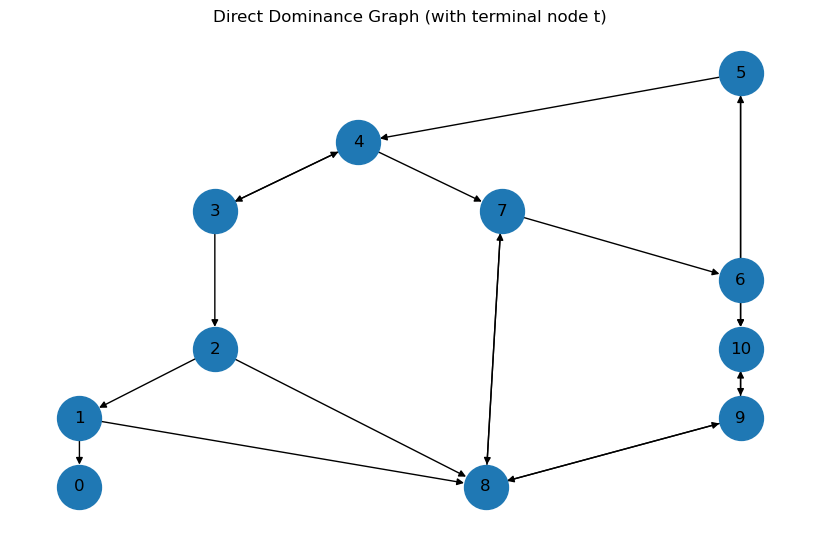

エッジ: [(5, 10), (6, 10), (9, 10), (8, 9), (1, 8), (2, 8), (7, 8), (4, 7), (3, 4)]


In [6]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_agraph import graphviz_layout  # pygraphvizが必要

def nearest_left_greater(arr):
    """スタックで左側の直近の大きい要素を求める"""
    n = len(arr)
    dom_idx = [-1] * n
    stack = []  # (値, インデックス)
    for j in range(n):
        while stack and stack[-1][0] <= arr[j]:
            stack.pop()
        if stack:
            dom_idx[j] = stack[-1][1]
        stack.append((arr[j], j))
    return dom_idx

def show_direct_dominance_graph(perm):
    dom_idx = nearest_left_greater(perm)
    k=len(perm)

    # エッジ作成
    edges = []
    for j, di in enumerate(dom_idx):
        src = k+1 if di == -1 else int(perm[di])
        tgt = int(perm[j])
        edges.append((tgt, src))

    # グラフ構築
    G = nx.DiGraph()
    G.add_nodes_from([int(x) for x in perm])
    G.add_edges_from(edges)
    
    #ハミルトンパス構築
    for i in range(k+1,0,-1):
        G.add_edge(i,i-1)
    
    # Graphvizレイアウト（階層構造）
    pos = graphviz_layout(G, prog="dot")
    # 描画/*
    plt.figure(figsize=(8, 5))
    nx.draw(G, pos, with_labels=True, node_size=1000, arrows=True, font_size=12)
    plt.title("Direct Dominance Graph (with terminal node t)")
    plt.show()
    

    print("エッジ:", edges)
    return G

# 使用例
perm = np.array([5,6,9,8,1,2,7,4,3])
show_direct_dominance_graph(perm)


Original dominance edges: [('s', '5'), ('s', '6'), ('s', '9'), ('9', '8'), ('8', '1'), ('8', '2'), ('8', '7'), ('7', '4'), ('4', '3')]
Reversed edges: [('5', 's'), ('6', 's'), ('9', 's'), ('8', '9'), ('1', '8'), ('2', '8'), ('7', '8'), ('4', '7'), ('3', '4')]
ファイナル [('5', 's'), ('6', 's'), ('9', 's'), ('8', '9'), ('1', '8'), ('2', '8'), ('7', '8'), ('4', '7'), ('3', '4'), ('s', '9'), ('9', '8'), ('8', '7'), ('7', '6'), ('6', '5'), ('5', '4'), ('4', '3'), ('3', '2'), ('2', '1'), ('1', 't')]


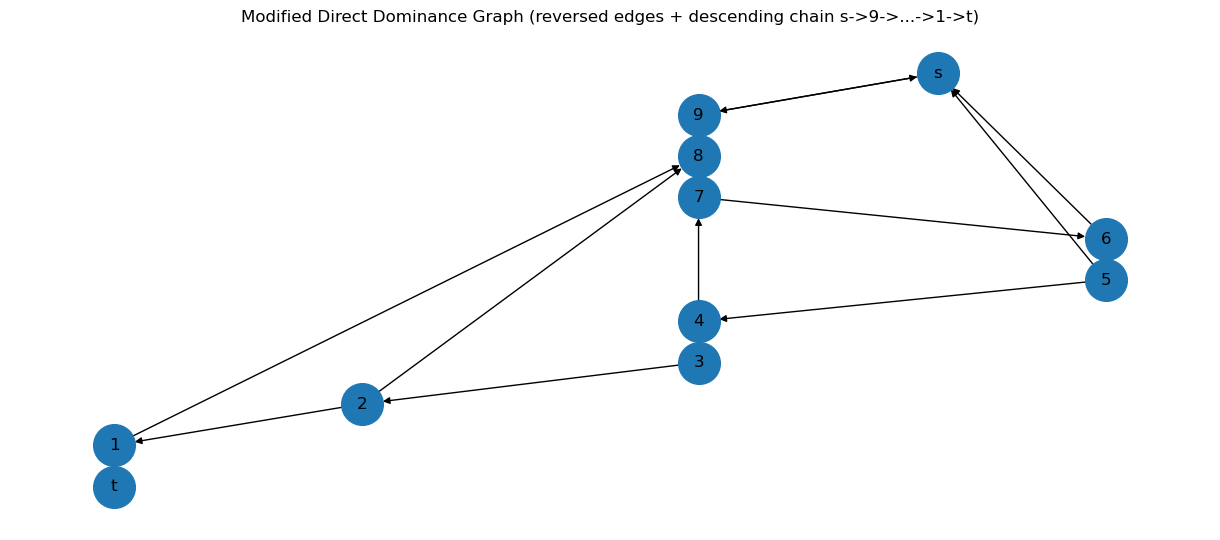

Final edges (19):
('5', 's')
('6', 's')
('9', 's')
('8', '9')
('1', '8')
('2', '8')
('7', '8')
('4', '7')
('3', '4')
('s', '9')
('9', '8')
('8', '7')
('7', '6')
('6', '5')
('5', '4')
('4', '3')
('3', '2')
('2', '1')
('1', 't')


In [7]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Optional: try using graphviz layout if available
try:
    from networkx.drawing.nx_agraph import graphviz_layout
    HAVE_GRAPHVIZ = True
except Exception:
    HAVE_GRAPHVIZ = False

def nearest_left_greater(arr):
    """O(n) stack method: return dominator indices (nearest left greater), -1 for 's'."""
    n = len(arr)
    dom_idx = [-1] * n
    stack = []  # (value, index)
    for j in range(n):
        while stack and stack[-1][0] <= arr[j]:
            stack.pop()
        if stack:
            dom_idx[j] = stack[-1][1]
        stack.append((arr[j], j))
    return dom_idx

def build_direct_dominance_edges(perm):
    """Return list of edges (src, tgt) using 's' for roots."""
    dom_idx = nearest_left_greater(perm)
    edges = []
    for j, di in enumerate(dom_idx):
        src = 's' if di == -1 else str(int(perm[di]))
        tgt = str(int(perm[j]))
        edges.append((src, tgt))
    return edges

def reverse_edges(edges):
    """Return new list with each edge reversed (tgt, src)."""
    return [(t, s) for (s, t) in edges]

def add_chain_edges(edges, perm, include_s=True, include_t=True):
    """
    Add chain edges s -> max -> ... -> min -> t,
    where chain nodes are the values in descending order (excluding 's' and 't').
    For the user request: chain s,9,8,7,...,3,2,1,t.
    """
    # Get sorted descending unique values from perm as strings
    vals_desc = sorted([int(x) for x in perm], reverse=True)
    chain_nodes = [str(v) for v in vals_desc]  # ['9','8',...,'1']

    chain = []
    if include_s:
        # s -> first
        chain.append(('s', chain_nodes[0]))
    # consecutive links
    for a, b in zip(chain_nodes, chain_nodes[1:]):
        chain.append((a, b))
    if include_t:
        chain.append((chain_nodes[-1], 't'))
    # add chain edges while avoiding duplicates
    for e in chain:
        if e not in edges:
            edges.append(e)
    return edges

def build_and_show_modified_graph(perm):
    # Build original dominance edges
    base_edges = build_direct_dominance_edges(perm)
    print("Original dominance edges:", base_edges)

    # Reverse all original edges
    reversed_edges = reverse_edges(base_edges)
    print("Reversed edges:", reversed_edges)

    # Start graph edges with reversed edges
    final_edges = list(reversed_edges)  # copy

    # Add chain s -> 9 -> 8 -> ... -> 1 -> t (descending values)
    final_edges = add_chain_edges(final_edges, perm, include_s=True, include_t=True)
    print("ファイナル",final_edges)
    
    # Build directed graph
    G = nx.DiGraph()
    # add nodes: s, t and permutation values (as strings)
    G.add_node('s')
    G.add_node('t')
    for v in perm:
        G.add_node(str(int(v)))
    # add edges (ensure uniqueness)
    G.add_edges_from(final_edges)

    # Choose layout
    if HAVE_GRAPHVIZ:
        pos = graphviz_layout(G, prog="dot")
    else:
        # fallback: try a layered layout by placing s and t, and perm nodes horizontally with varying y
        # We'll compute depths roughly to put chain visually descending
        # simple fallback: x = index, y = 0 for s, y = -index for nodes in descending order for clarity
        pos = {}
        # place perm values horizontally by their original index
        for i, v in enumerate(perm):
            pos[str(int(v))] = (i, 0)
        pos['s'] = (-1, 0)
        pos['t'] = (len(perm), 0)

    # Draw
    plt.figure(figsize=(12, 5))
    nx.draw(G, pos, with_labels=True, node_size=900, arrows=True, font_size=12)
    plt.title("Modified Direct Dominance Graph (reversed edges + descending chain s->9->...->1->t)")
    plt.axis('off')
    plt.show()

    # Print final edges
    print("Final edges ({}):".format(len(final_edges)))
    for e in final_edges:
        print(e)

# Example usage
perm = np.array([5,6,9,8,1,2,7,4,3])
#perm = np.array([4,2,3,6,7,5,8,9,1,10,13,11,12])
build_and_show_modified_graph(perm)


S= 1318933
生成文字列: 00000000000000000100110011000000000
NumPy配列: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 0 0 1 1 0 0 0 0 0 0 0 0 0]
[18 21 22 25 26 35 34 33 32 31 30 29 28 27 24 23 20  1 19 17  2  3 16 15
  4  5 14 13 12 11 10  9  8  7  6]
Original dominance edges: [('s', '18'), ('s', '21'), ('s', '22'), ('s', '25'), ('s', '26'), ('s', '35'), ('35', '34'), ('34', '33'), ('33', '32'), ('32', '31'), ('31', '30'), ('30', '29'), ('29', '28'), ('28', '27'), ('27', '24'), ('24', '23'), ('23', '20'), ('20', '1'), ('20', '19'), ('19', '17'), ('17', '2'), ('17', '3'), ('17', '16'), ('16', '15'), ('15', '4'), ('15', '5'), ('15', '14'), ('14', '13'), ('13', '12'), ('12', '11'), ('11', '10'), ('10', '9'), ('9', '8'), ('8', '7'), ('7', '6')]
Reversed edges: [('18', 's'), ('21', 's'), ('22', 's'), ('25', 's'), ('26', 's'), ('35', 's'), ('34', '35'), ('33', '34'), ('32', '33'), ('31', '32'), ('30', '31'), ('29', '30'), ('28', '29'), ('27', '28'), ('24', '27'), ('23', '24'), ('20', '23'), ('1', '20

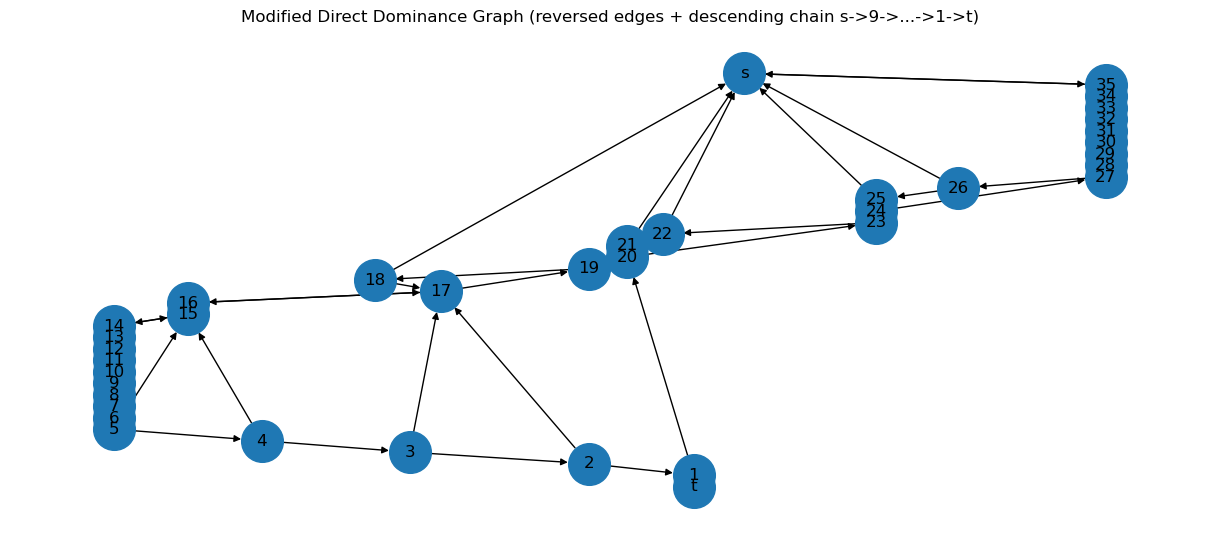

Final edges (71):
('18', 's')
('21', 's')
('22', 's')
('25', 's')
('26', 's')
('35', 's')
('34', '35')
('33', '34')
('32', '33')
('31', '32')
('30', '31')
('29', '30')
('28', '29')
('27', '28')
('24', '27')
('23', '24')
('20', '23')
('1', '20')
('19', '20')
('17', '19')
('2', '17')
('3', '17')
('16', '17')
('15', '16')
('4', '15')
('5', '15')
('14', '15')
('13', '14')
('12', '13')
('11', '12')
('10', '11')
('9', '10')
('8', '9')
('7', '8')
('6', '7')
('s', '35')
('35', '34')
('34', '33')
('33', '32')
('32', '31')
('31', '30')
('30', '29')
('29', '28')
('28', '27')
('27', '26')
('26', '25')
('25', '24')
('24', '23')
('23', '22')
('22', '21')
('21', '20')
('20', '19')
('19', '18')
('18', '17')
('17', '16')
('16', '15')
('15', '14')
('14', '13')
('13', '12')
('12', '11')
('11', '10')
('10', '9')
('9', '8')
('8', '7')
('7', '6')
('6', '5')
('5', '4')
('4', '3')
('3', '2')
('2', '1')
('1', 't')


In [8]:
#Sに対してπ*を出力するコード

import random

def S_RPG(S:int):
#S->π*のコード
    B = wi_bit_code(S)
    Pi_b = binary_to_perm(B)
    Pi_str = inverse_permutation(Pi_b)
    print(Pi_str)

#π*->RPGのコード
    build_and_show_modified_graph(Pi_str)
    
S=int(random.randint(1100000,2000000))
print("S=",S)
S_RPG(78592)


S= 1299048
[ 157  410  564  806 1114 1400 1764 2521 2725 3697]
生成文字列: 00000000100111010
NumPy配列: [0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 1 0]
[ 9 12 13 14 16 17 15 11  1 10  8  2  3  4  7  5  6]
Original dominance edges: [('s', '9'), ('s', '12'), ('s', '13'), ('s', '14'), ('s', '16'), ('s', '17'), ('17', '15'), ('15', '11'), ('11', '1'), ('11', '10'), ('10', '8'), ('8', '2'), ('8', '3'), ('8', '4'), ('8', '7'), ('7', '5'), ('7', '6')]
Reversed edges: [('9', 's'), ('12', 's'), ('13', 's'), ('14', 's'), ('16', 's'), ('17', 's'), ('15', '17'), ('11', '15'), ('1', '11'), ('10', '11'), ('8', '10'), ('2', '8'), ('3', '8'), ('4', '8'), ('7', '8'), ('5', '7'), ('6', '7')]
ファイナル [('9', 's'), ('12', 's'), ('13', 's'), ('14', 's'), ('16', 's'), ('17', 's'), ('15', '17'), ('11', '15'), ('1', '11'), ('10', '11'), ('8', '10'), ('2', '8'), ('3', '8'), ('4', '8'), ('7', '8'), ('5', '7'), ('6', '7'), ('s', '17'), ('17', '16'), ('16', '15'), ('15', '14'), ('14', '13'), ('13', '12'), ('12', '11'), ('11', '10'), (

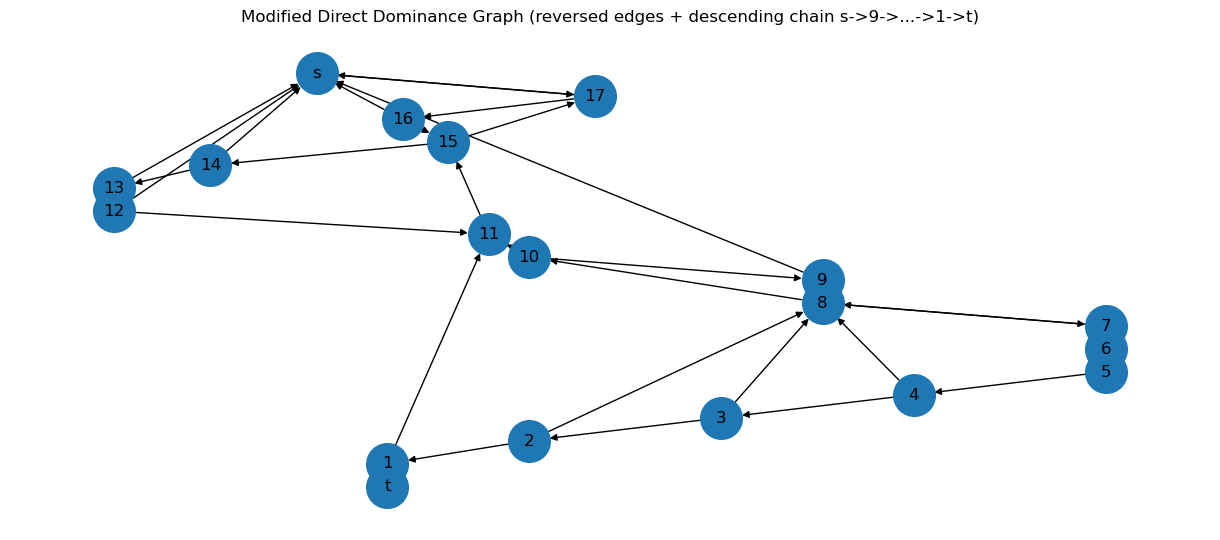

Final edges (35):
('9', 's')
('12', 's')
('13', 's')
('14', 's')
('16', 's')
('17', 's')
('15', '17')
('11', '15')
('1', '11')
('10', '11')
('8', '10')
('2', '8')
('3', '8')
('4', '8')
('7', '8')
('5', '7')
('6', '7')
('s', '17')
('17', '16')
('16', '15')
('15', '14')
('14', '13')
('13', '12')
('12', '11')
('11', '10')
('10', '9')
('9', '8')
('8', '7')
('7', '6')
('6', '5')
('5', '4')
('4', '3')
('3', '2')
('2', '1')
('1', 't')
生成文字列: 0000000001100110100
NumPy配列: [0 0 0 0 0 0 0 0 0 1 1 0 0 1 1 0 1 0 0]
[10 11 14 15 17 19 18 16 13  1  2 12  9  3  4  8  5  7  6]
Original dominance edges: [('s', '10'), ('s', '11'), ('s', '14'), ('s', '15'), ('s', '17'), ('s', '19'), ('19', '18'), ('18', '16'), ('16', '13'), ('13', '1'), ('13', '2'), ('13', '12'), ('12', '9'), ('9', '3'), ('9', '4'), ('9', '8'), ('8', '5'), ('8', '7'), ('7', '6')]
Reversed edges: [('10', 's'), ('11', 's'), ('14', 's'), ('15', 's'), ('17', 's'), ('19', 's'), ('18', '19'), ('16', '18'), ('13', '16'), ('1', '13'), ('2', '13')

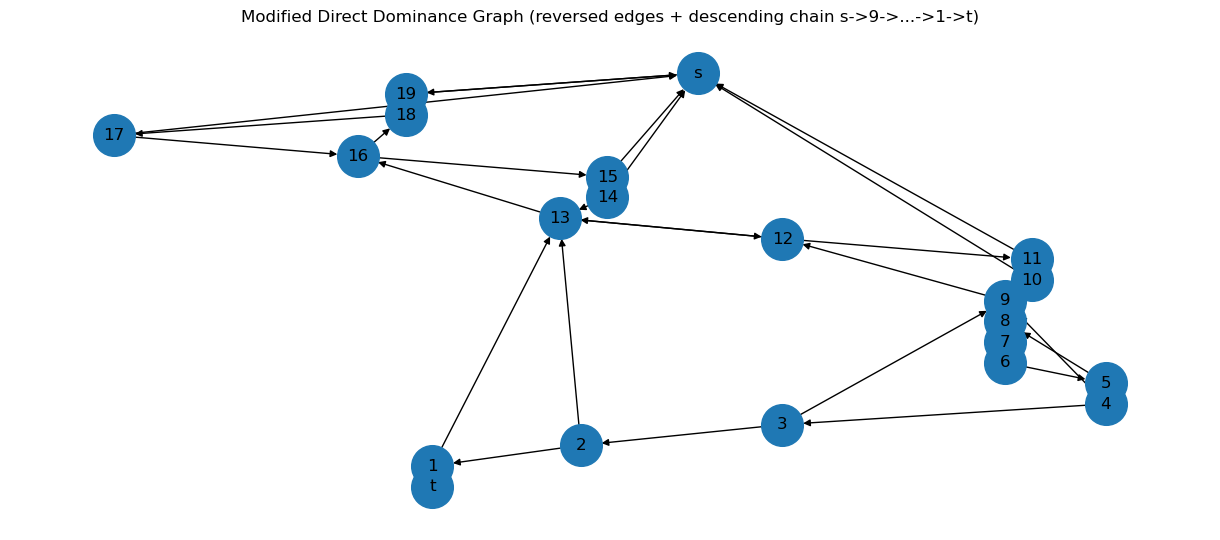

Final edges (39):
('10', 's')
('11', 's')
('14', 's')
('15', 's')
('17', 's')
('19', 's')
('18', '19')
('16', '18')
('13', '16')
('1', '13')
('2', '13')
('12', '13')
('9', '12')
('3', '9')
('4', '9')
('8', '9')
('5', '8')
('7', '8')
('6', '7')
('s', '19')
('19', '18')
('18', '17')
('17', '16')
('16', '15')
('15', '14')
('14', '13')
('13', '12')
('12', '11')
('11', '10')
('10', '9')
('9', '8')
('8', '7')
('7', '6')
('6', '5')
('5', '4')
('4', '3')
('3', '2')
('2', '1')
('1', 't')
生成文字列: 000000000010001101000
NumPy配列: [0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 1 0 1 0 0 0]
[11 15 16 18 21 20 19 17 14 13  1 12 10  9  2  3  8  4  7  6  5]
Original dominance edges: [('s', '11'), ('s', '15'), ('s', '16'), ('s', '18'), ('s', '21'), ('21', '20'), ('20', '19'), ('19', '17'), ('17', '14'), ('14', '13'), ('13', '1'), ('13', '12'), ('12', '10'), ('10', '9'), ('9', '2'), ('9', '3'), ('9', '8'), ('8', '4'), ('8', '7'), ('7', '6'), ('6', '5')]
Reversed edges: [('11', 's'), ('15', 's'), ('16', 's'), ('18', 's'), 

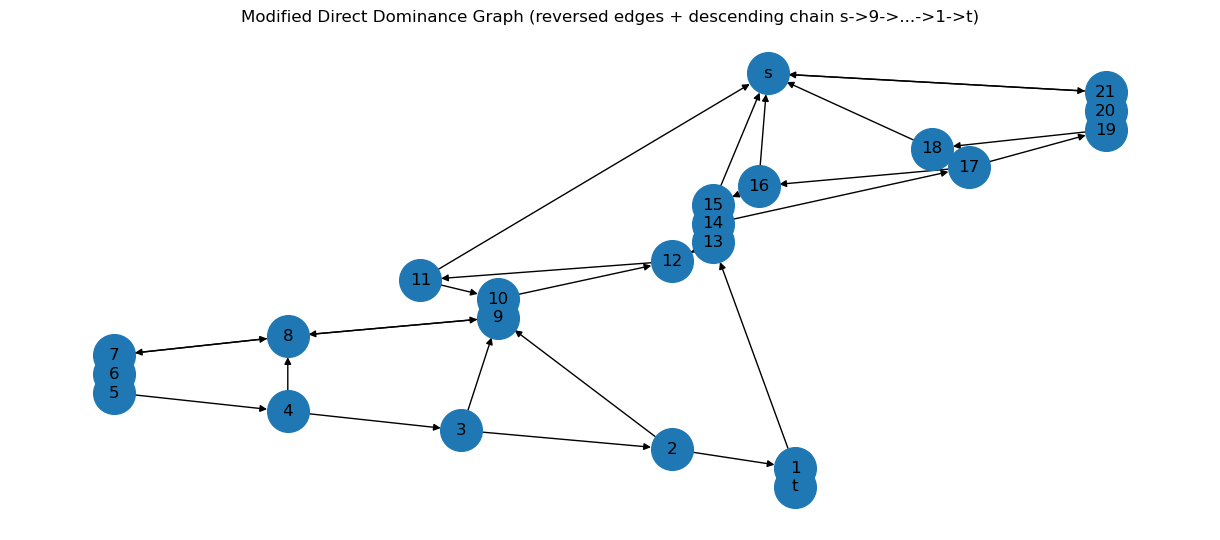

Final edges (43):
('11', 's')
('15', 's')
('16', 's')
('18', 's')
('21', 's')
('20', '21')
('19', '20')
('17', '19')
('14', '17')
('13', '14')
('1', '13')
('12', '13')
('10', '12')
('9', '10')
('2', '9')
('3', '9')
('8', '9')
('4', '8')
('7', '8')
('6', '7')
('5', '6')
('s', '21')
('21', '20')
('20', '19')
('19', '18')
('18', '17')
('17', '16')
('16', '15')
('15', '14')
('14', '13')
('13', '12')
('12', '11')
('11', '10')
('10', '9')
('9', '8')
('8', '7')
('7', '6')
('6', '5')
('5', '4')
('4', '3')
('3', '2')
('2', '1')
('1', 't')
生成文字列: 000000000011001001100
NumPy配列: [0 0 0 0 0 0 0 0 0 0 1 1 0 0 1 0 0 1 1 0 0]
[11 12 15 18 19 21 20 17 16 14  1  2 13 10  3  9  8  4  5  7  6]
Original dominance edges: [('s', '11'), ('s', '12'), ('s', '15'), ('s', '18'), ('s', '19'), ('s', '21'), ('21', '20'), ('20', '17'), ('17', '16'), ('16', '14'), ('14', '1'), ('14', '2'), ('14', '13'), ('13', '10'), ('10', '3'), ('10', '9'), ('9', '8'), ('8', '4'), ('8', '5'), ('8', '7'), ('7', '6')]
Reversed edges: 

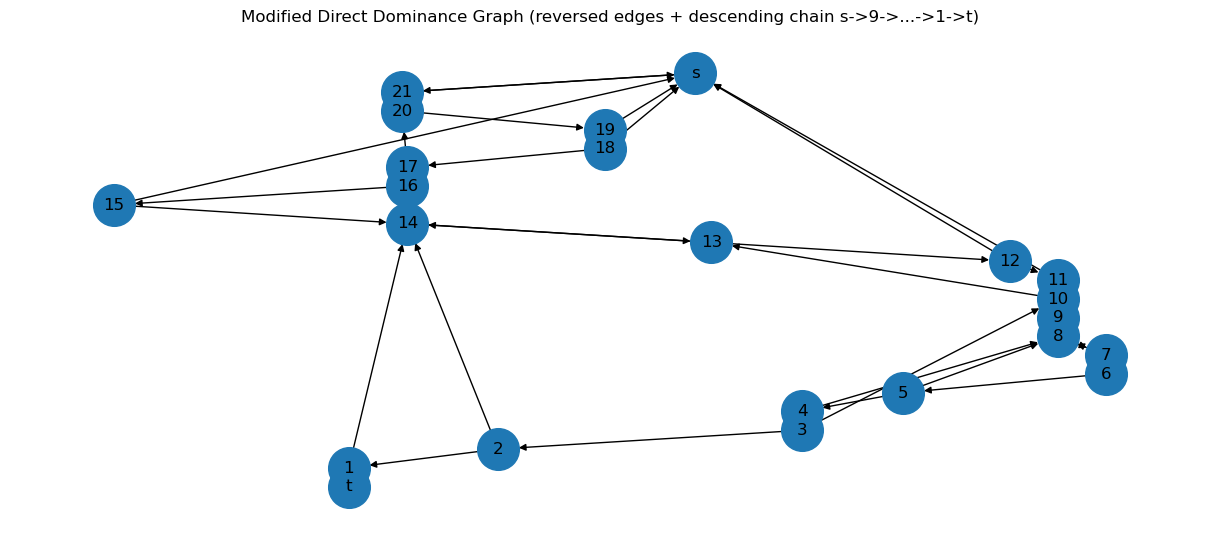

Final edges (43):
('11', 's')
('12', 's')
('15', 's')
('18', 's')
('19', 's')
('21', 's')
('20', '21')
('17', '20')
('16', '17')
('14', '16')
('1', '14')
('2', '14')
('13', '14')
('10', '13')
('3', '10')
('9', '10')
('8', '9')
('4', '8')
('5', '8')
('7', '8')
('6', '7')
('s', '21')
('21', '20')
('20', '19')
('19', '18')
('18', '17')
('17', '16')
('16', '15')
('15', '14')
('14', '13')
('13', '12')
('12', '11')
('11', '10')
('10', '9')
('9', '8')
('8', '7')
('7', '6')
('6', '5')
('5', '4')
('4', '3')
('3', '2')
('2', '1')
('1', 't')
生成文字列: 00000000000100010110100
NumPy配列: [0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 1 1 0 1 0 0]
[12 16 18 19 21 23 22 20 17 15 14  1 13 11 10  2  9  3  4  8  5  7  6]
Original dominance edges: [('s', '12'), ('s', '16'), ('s', '18'), ('s', '19'), ('s', '21'), ('s', '23'), ('23', '22'), ('22', '20'), ('20', '17'), ('17', '15'), ('15', '14'), ('14', '1'), ('14', '13'), ('13', '11'), ('11', '10'), ('10', '2'), ('10', '9'), ('9', '3'), ('9', '4'), ('9', '8'), ('8', '5'), 

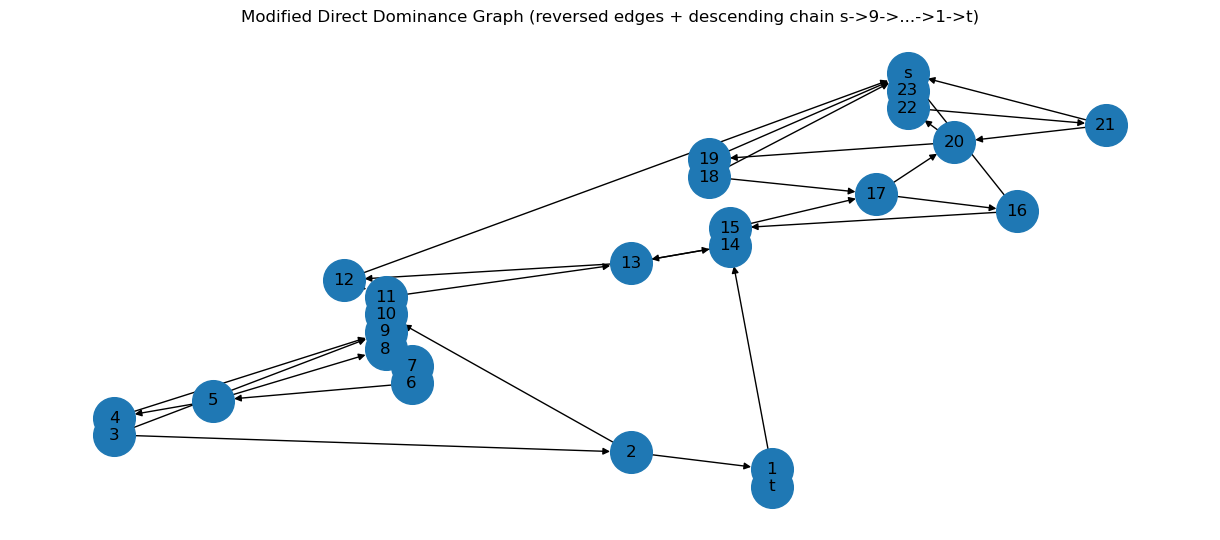

Final edges (47):
('12', 's')
('16', 's')
('18', 's')
('19', 's')
('21', 's')
('23', 's')
('22', '23')
('20', '22')
('17', '20')
('15', '17')
('14', '15')
('1', '14')
('13', '14')
('11', '13')
('10', '11')
('2', '10')
('9', '10')
('3', '9')
('4', '9')
('8', '9')
('5', '8')
('7', '8')
('6', '7')
('s', '23')
('23', '22')
('22', '21')
('21', '20')
('20', '19')
('19', '18')
('18', '17')
('17', '16')
('16', '15')
('15', '14')
('14', '13')
('13', '12')
('12', '11')
('11', '10')
('10', '9')
('9', '8')
('8', '7')
('7', '6')
('6', '5')
('5', '4')
('4', '3')
('3', '2')
('2', '1')
('1', 't')
生成文字列: 00000000000101011110000
NumPy配列: [0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 1 1 1 0 0 0 0]
[12 14 16 17 18 19 23 22 21 20 15  1 13  2 11  3  4  5  6 10  9  8  7]
Original dominance edges: [('s', '12'), ('s', '14'), ('s', '16'), ('s', '17'), ('s', '18'), ('s', '19'), ('s', '23'), ('23', '22'), ('22', '21'), ('21', '20'), ('20', '15'), ('15', '1'), ('15', '13'), ('13', '2'), ('13', '11'), ('11', '3'), ('11', '4'),

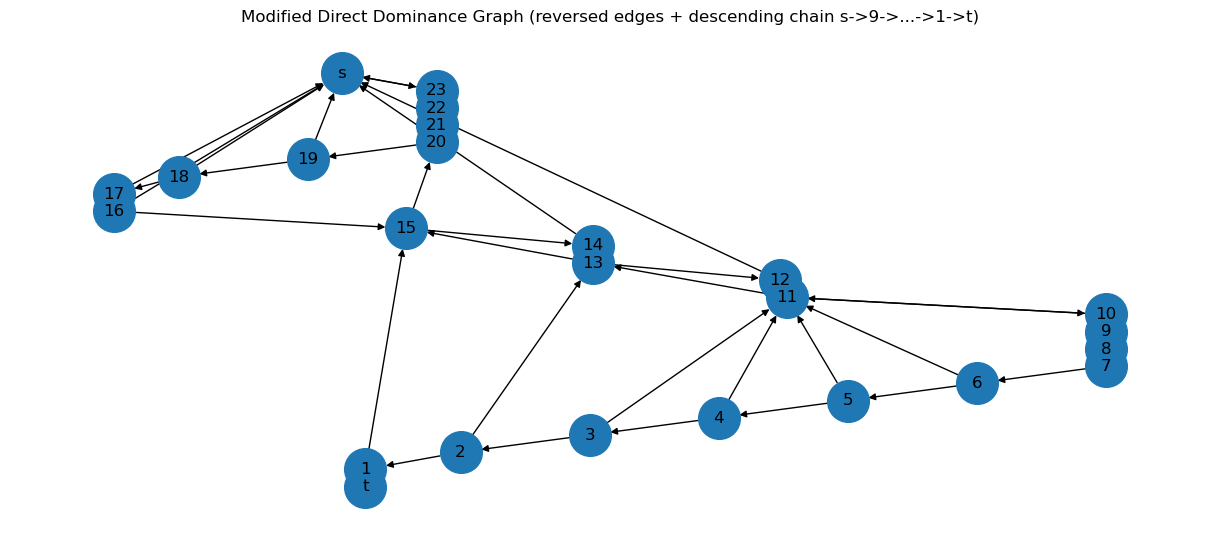

Final edges (47):
('12', 's')
('14', 's')
('16', 's')
('17', 's')
('18', 's')
('19', 's')
('23', 's')
('22', '23')
('21', '22')
('20', '21')
('15', '20')
('1', '15')
('13', '15')
('2', '13')
('11', '13')
('3', '11')
('4', '11')
('5', '11')
('6', '11')
('10', '11')
('9', '10')
('8', '9')
('7', '8')
('s', '23')
('23', '22')
('22', '21')
('21', '20')
('20', '19')
('19', '18')
('18', '17')
('17', '16')
('16', '15')
('15', '14')
('14', '13')
('13', '12')
('12', '11')
('11', '10')
('10', '9')
('9', '8')
('8', '7')
('7', '6')
('6', '5')
('5', '4')
('4', '3')
('3', '2')
('2', '1')
('1', 't')
生成文字列: 00000000000110111001000
NumPy配列: [0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 1 0 0 1 0 0 0]
[12 13 15 16 17 20 23 22 21 19 18  1  2 14  3  4  5 11 10  6  9  8  7]
Original dominance edges: [('s', '12'), ('s', '13'), ('s', '15'), ('s', '16'), ('s', '17'), ('s', '20'), ('s', '23'), ('23', '22'), ('22', '21'), ('21', '19'), ('19', '18'), ('18', '1'), ('18', '2'), ('18', '14'), ('14', '3'), ('14', '4'), ('14', '5'

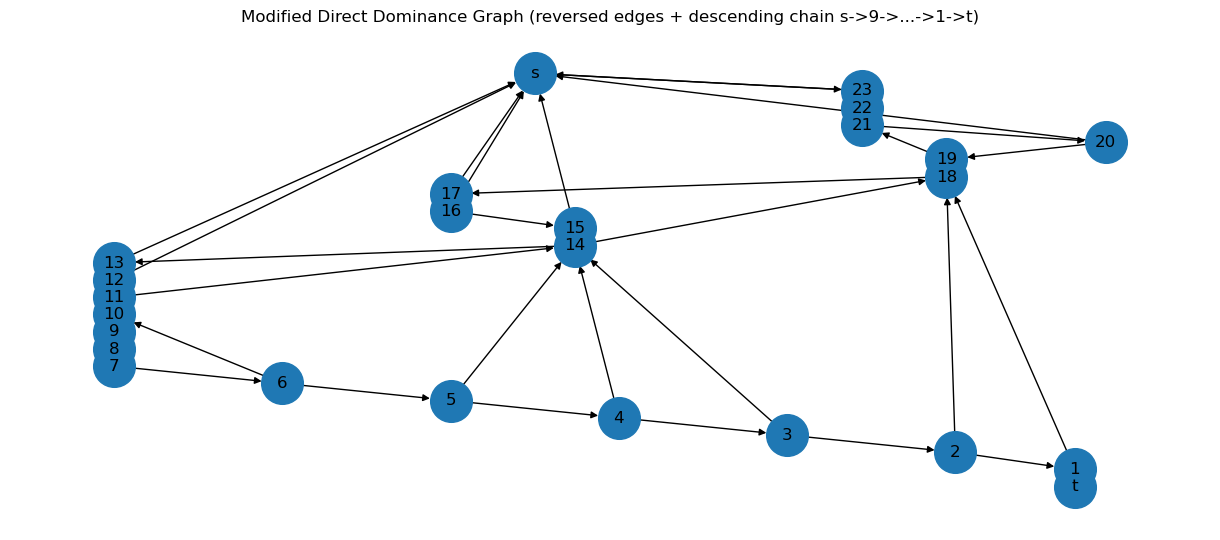

Final edges (47):
('12', 's')
('13', 's')
('15', 's')
('16', 's')
('17', 's')
('20', 's')
('23', 's')
('22', '23')
('21', '22')
('19', '21')
('18', '19')
('1', '18')
('2', '18')
('14', '18')
('3', '14')
('4', '14')
('5', '14')
('11', '14')
('10', '11')
('6', '10')
('9', '10')
('8', '9')
('7', '8')
('s', '23')
('23', '22')
('22', '21')
('21', '20')
('20', '19')
('19', '18')
('18', '17')
('17', '16')
('16', '15')
('15', '14')
('14', '13')
('13', '12')
('12', '11')
('11', '10')
('10', '9')
('9', '8')
('8', '7')
('7', '6')
('6', '5')
('5', '4')
('4', '3')
('3', '2')
('2', '1')
('1', 't')
生成文字列: 0000000000001001110110010
NumPy配列: [0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 1 1 0 0 1 0]
[13 16 17 18 20 21 24 25 23 22 19 15  1 14 12  2  3  4 11  5  6 10  9  7
  8]
Original dominance edges: [('s', '13'), ('s', '16'), ('s', '17'), ('s', '18'), ('s', '20'), ('s', '21'), ('s', '24'), ('s', '25'), ('25', '23'), ('23', '22'), ('22', '19'), ('19', '15'), ('15', '1'), ('15', '14'), ('14', '12'), ('12', '2

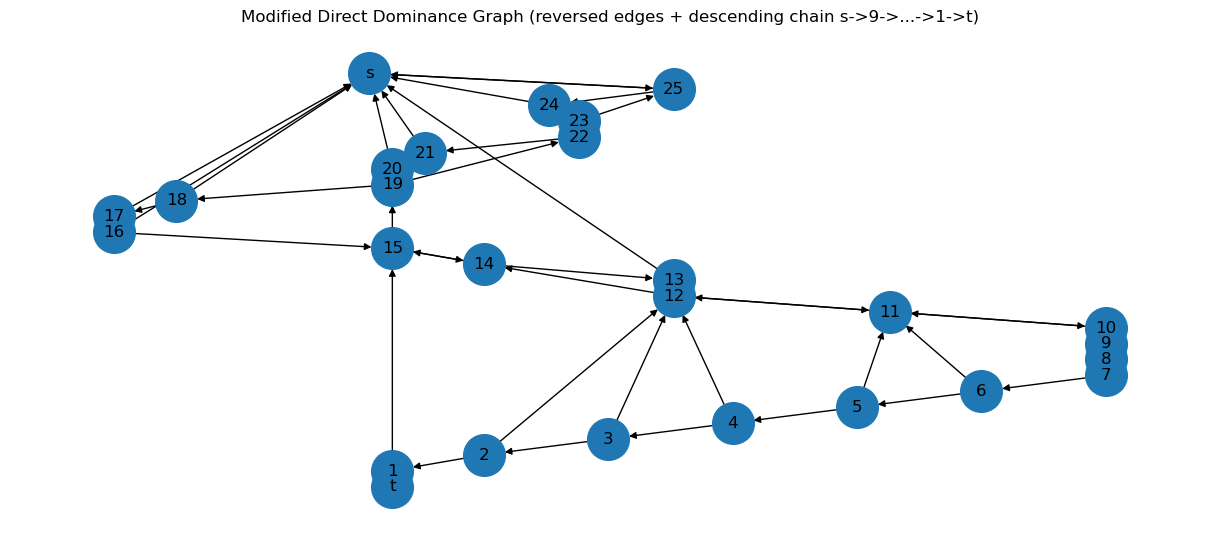

Final edges (51):
('13', 's')
('16', 's')
('17', 's')
('18', 's')
('20', 's')
('21', 's')
('24', 's')
('25', 's')
('23', '25')
('22', '23')
('19', '22')
('15', '19')
('1', '15')
('14', '15')
('12', '14')
('2', '12')
('3', '12')
('4', '12')
('11', '12')
('5', '11')
('6', '11')
('10', '11')
('9', '10')
('7', '9')
('8', '9')
('s', '25')
('25', '24')
('24', '23')
('23', '22')
('22', '21')
('21', '20')
('20', '19')
('19', '18')
('18', '17')
('17', '16')
('16', '15')
('15', '14')
('14', '13')
('13', '12')
('12', '11')
('11', '10')
('10', '9')
('9', '8')
('8', '7')
('7', '6')
('6', '5')
('5', '4')
('4', '3')
('3', '2')
('2', '1')
('1', 't')
生成文字列: 0000000000001010101001010
NumPy配列: [0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 0 1 0 1 0 0 1 0 1 0]
[13 15 17 19 22 24 25 23 21 20 18 16  1 14  2 12  3 11  4 10  9  5  8  6
  7]
Original dominance edges: [('s', '13'), ('s', '15'), ('s', '17'), ('s', '19'), ('s', '22'), ('s', '24'), ('s', '25'), ('25', '23'), ('23', '21'), ('21', '20'), ('20', '18'), ('18', '16')

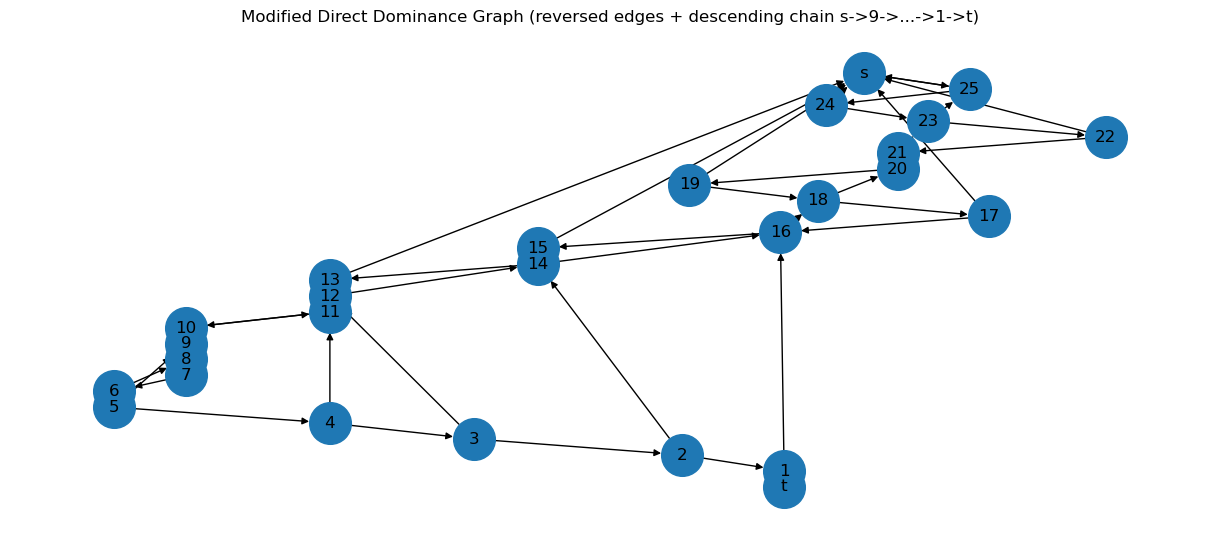

Final edges (51):
('13', 's')
('15', 's')
('17', 's')
('19', 's')
('22', 's')
('24', 's')
('25', 's')
('23', '25')
('21', '23')
('20', '21')
('18', '20')
('16', '18')
('1', '16')
('14', '16')
('2', '14')
('12', '14')
('3', '12')
('11', '12')
('4', '11')
('10', '11')
('9', '10')
('5', '9')
('8', '9')
('6', '8')
('7', '8')
('s', '25')
('25', '24')
('24', '23')
('23', '22')
('22', '21')
('21', '20')
('20', '19')
('19', '18')
('18', '17')
('17', '16')
('16', '15')
('15', '14')
('14', '13')
('13', '12')
('12', '11')
('11', '10')
('10', '9')
('9', '8')
('8', '7')
('7', '6')
('6', '5')
('5', '4')
('4', '3')
('3', '2')
('2', '1')
('1', 't')
生成文字列: 0000000000001110011100010
NumPy配列: [0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 1 1 1 0 0 0 1 0]
[13 14 15 18 19 20 24 25 23 22 21 17  1  2  3 16 12  4  5  6 11 10  9  7
  8]
Original dominance edges: [('s', '13'), ('s', '14'), ('s', '15'), ('s', '18'), ('s', '19'), ('s', '20'), ('s', '24'), ('s', '25'), ('25', '23'), ('23', '22'), ('22', '21'), ('21', '17'), 

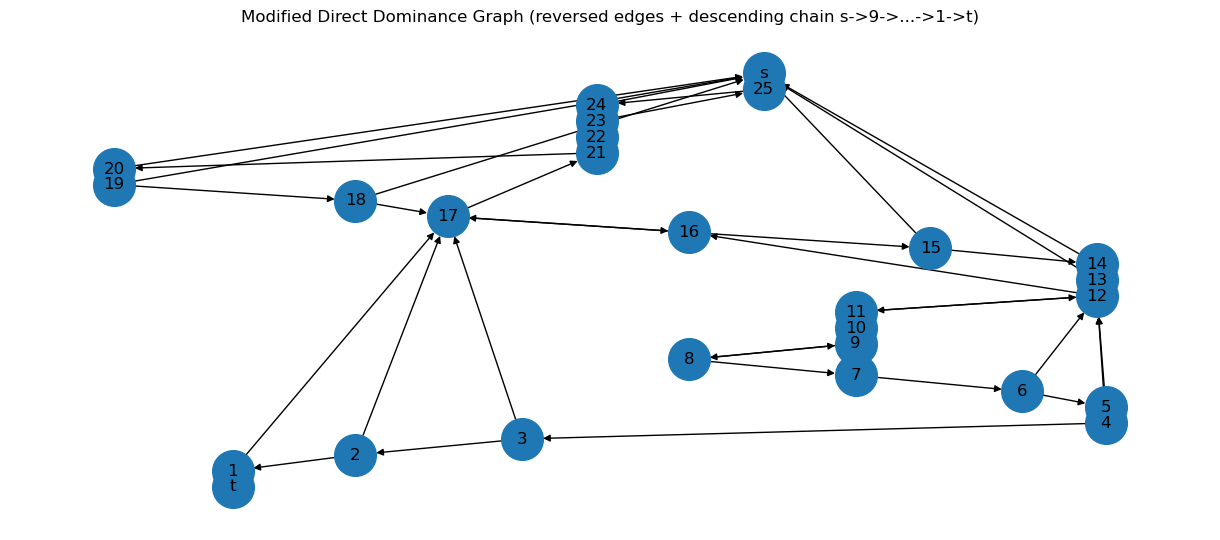

Final edges (51):
('13', 's')
('14', 's')
('15', 's')
('18', 's')
('19', 's')
('20', 's')
('24', 's')
('25', 's')
('23', '25')
('22', '23')
('21', '22')
('17', '21')
('1', '17')
('2', '17')
('3', '17')
('16', '17')
('12', '16')
('4', '12')
('5', '12')
('6', '12')
('11', '12')
('10', '11')
('9', '10')
('7', '9')
('8', '9')
('s', '25')
('25', '24')
('24', '23')
('23', '22')
('22', '21')
('21', '20')
('20', '19')
('19', '18')
('18', '17')
('17', '16')
('16', '15')
('15', '14')
('14', '13')
('13', '12')
('12', '11')
('11', '10')
('10', '9')
('9', '8')
('8', '7')
('7', '6')
('6', '5')
('5', '4')
('4', '3')
('3', '2')
('2', '1')
('1', 't')


In [9]:
#Sに対して、CRTを適用して、Pi_strを出力
import random
S=int(random.randint(1100000,2000000))
print("S=",S)

#S->CRT->RPG
Wi = S_W_Code(S,10,25)
print(Wi)
for num in Wi:
    S_RPG(num)


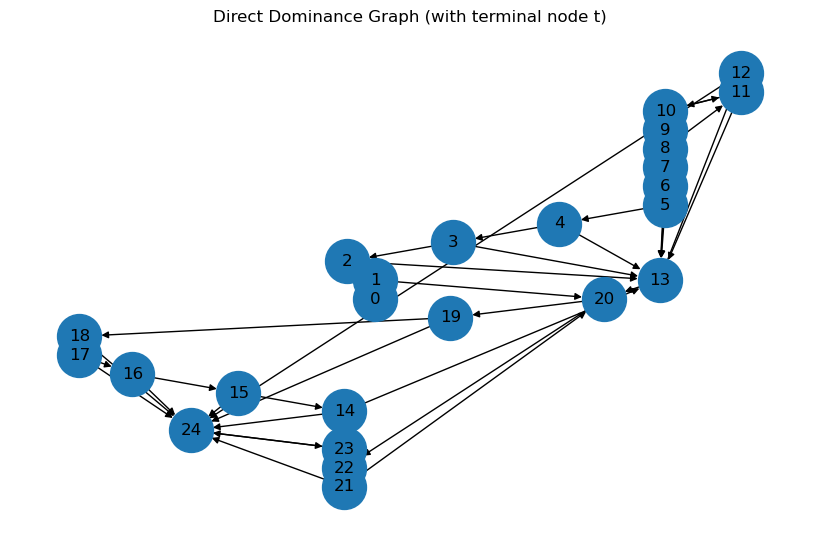

エッジ: [(12, 24), (14, 24), (15, 24), (16, 24), (17, 24), (18, 24), (19, 24), (21, 24), (23, 24), (22, 23), (20, 22), (1, 20), (13, 20), (2, 13), (3, 13), (4, 13), (5, 13), (6, 13), (7, 13), (11, 13), (8, 11), (10, 11), (9, 10)]
削除したエッジ [(5, 4), (19, 18), (4, 3), (20, 22)]


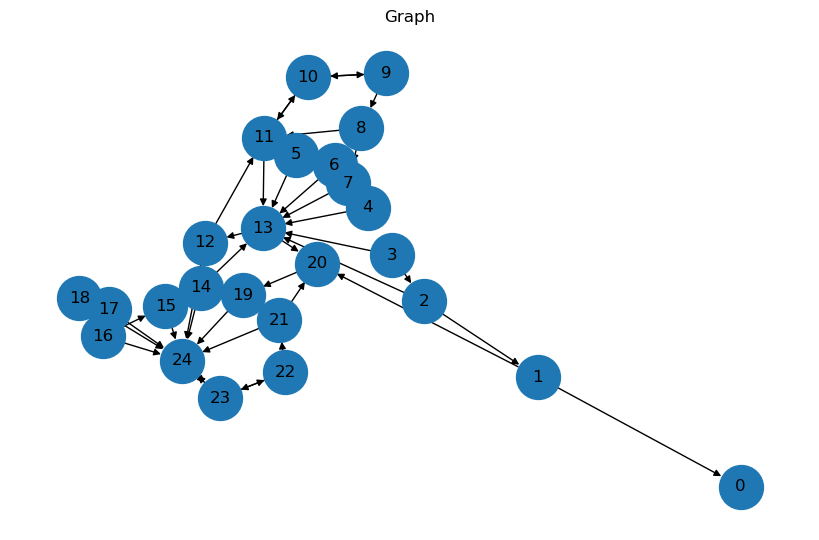

In [10]:
import random
import networkx as nx
import matplotlib.pyplot as plt

def edge_deletion_attack(G, num_edges=4, random_seed=None):
    """
    仮想的にエッジ削除攻撃を行う
    G : 攻撃対象グラフ (nx.DiGraph)
    num_edges : 削除するエッジ数
    random_seed : 再現性のための乱数シード
    """
    if random_seed is not None:
        random.seed(random_seed)

    G_attacked = G.copy()
    edges = list(G_attacked.edges())

    # 削除するエッジをランダムに選択
    removed_edges = random.sample(edges, min(num_edges, len(edges)))

    # エッジ削除
    G_attacked.remove_edges_from(removed_edges)
    print("削除したエッジ",removed_edges)

    return G_attacked

def show_graph(G, title="Graph"):
    pos = nx.spring_layout(G, seed=42)
    plt.figure(figsize=(8, 5))
    nx.draw(G, pos, with_labels=True, node_size=1000, arrows=True, font_size=12)
    plt.title(title)
    plt.show()

show_graph(edge_deletion_attack(show_direct_dominance_graph(np.array([12,14,15,16,17,18,19,21,23,22,20,1,13,2,3,4,5,6,7,11,8,10,9]))))

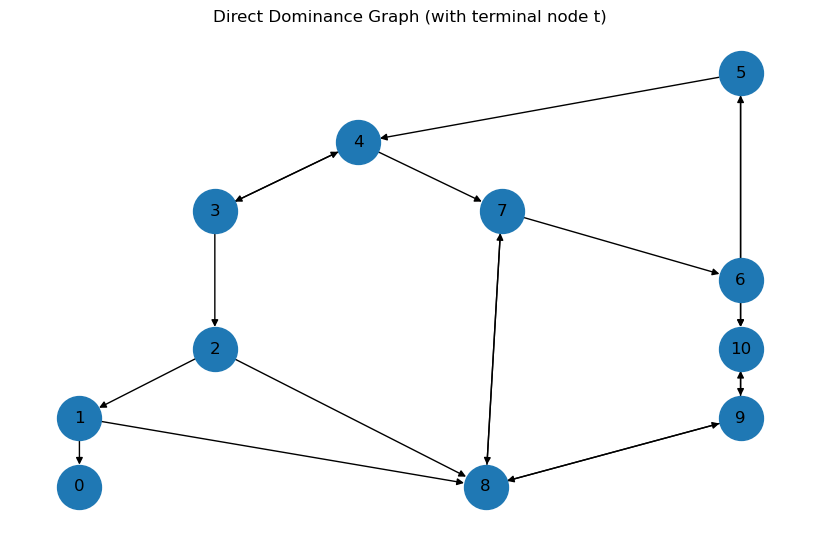

エッジ: [(5, 10), (6, 10), (9, 10), (8, 9), (1, 8), (2, 8), (7, 8), (4, 7), (3, 4)]
削除したエッジ [(1, 8), (9, 10), (6, 5), (5, 10)]
出実数が2未満 9
削除されたHP (6, 5)
出実数が2未満 5
出実数が2未満 1


In [11]:
import networkx as nx

#復元プログラム　ハミルトンパスの復元
def repair_HP(G):
    max_node=max(G.nodes())
    k = G.number_of_nodes()-1
    for i in range(k,0,-1):
        edge = (i,i-1)
        
        if not edge in G.edges:
            print("削除されたHP",edge)
            G.add_edge(*edge)
        
        if G.out_degree(i)<2 and i!=k:
            print("出実数が2未満",i)
            
    return G

def repair_Pi_str(G):
    a=0
    
repair_HP(edge_deletion_attack(show_direct_dominance_graph(np.array([5,6,9,8,1,2,7,4,3]))))
    
            
            
    
    

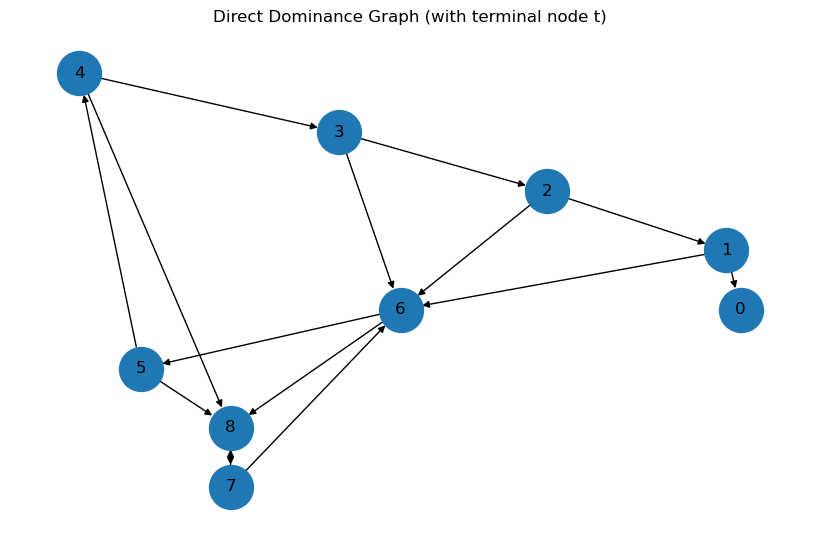

エッジ: [(4, 8), (5, 8), (6, 8), (1, 6), (2, 6), (3, 6), (7, 8)]
削除したエッジ [(5, 8), (7, 6), (3, 2), (8, 7)]
削除されたHP (8, 7)
削除されたHP (7, 6)
出実数が2未満 5
削除されたHP (3, 2)


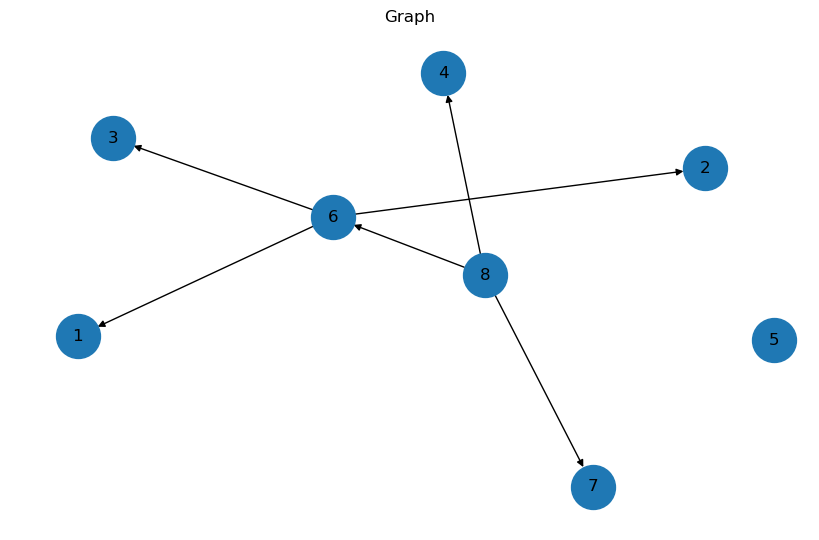

In [12]:
#RPGからDAG_Treeを復元
def RPG_DAG(G):
    for i in range(G.number_of_nodes()-1,0,-1):
        G.remove_edge(i,i-1)
    
    G.remove_node(0)
    G=nx.reverse(G)
    show_graph(G)
    return G
    
RPG_DAG(repair_HP(edge_deletion_attack(show_direct_dominance_graph(np.array([4,5,6,1,2,3,7])))))

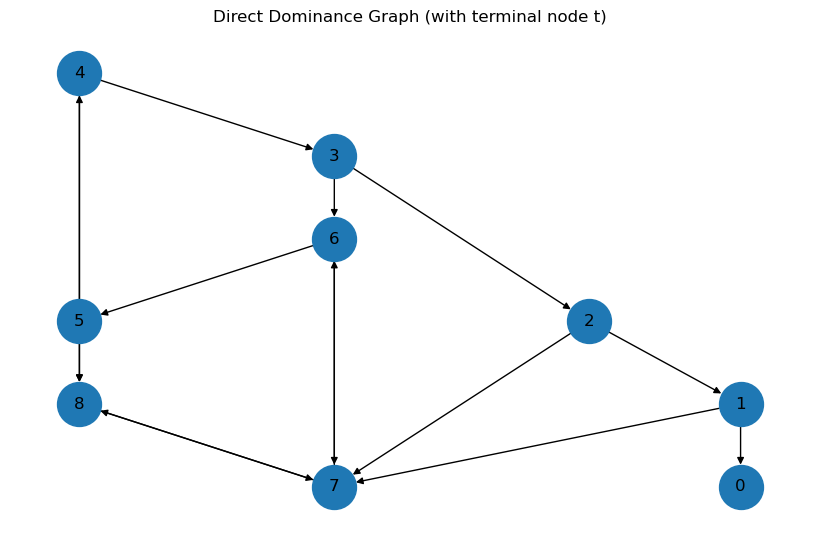

エッジ: [(4, 8), (5, 8), (7, 8), (1, 7), (2, 7), (6, 7), (3, 6)]
削除したエッジ [(5, 8), (4, 3), (3, 2), (6, 7)]
出実数が2未満 6
出実数が2未満 5
削除されたHP (4, 3)
削除されたHP (3, 2)


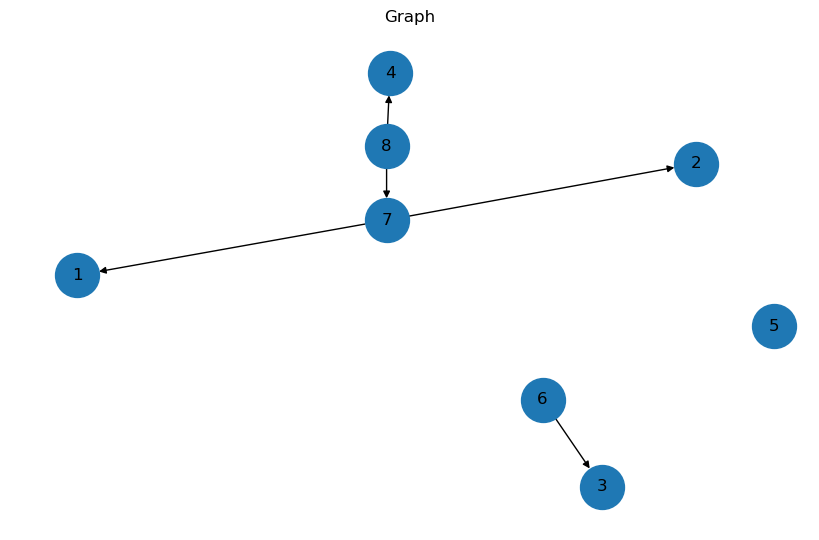

TypeError: iteration over a 0-d array

In [13]:
def define_f(G):
    #f=2n+1
    maxnodes=G.number_of_nodes()
    n=int((maxnodes-2)/2)
    check=True
    if G.out_degree(2*n+1) == 0:
        for i in range(1,n+1):
            if not (G.has_edge(2*n,i) or (G.degree(i) == 0)):
                check = False
                break
    else:
        check = False

    if check == True:
        print(2*n+1)
        return 2*n+1
    
    #f<2n+1 
    #(i)
    for i in range (1,G.number_of_nodes()):
        if G.out_degree(i) >= 2 and max(G.successors(i))>n:
            return max(G.successors(i))
    #(ii)
    components = [set(c) for c in nx.weakly_connected_components(G)]
    #部分偽の頂点集合を返す
    for x in range (n+1,2*n+1):
        Y_dash = np.arange(x-n,n)
        Y1 = G.successors(x)
        if all(x-n<k<n for k in np.array(Y1)) and Y1!=[]:
                Y2 = Y_dash[~np.isin(Y_dash,Y1)]
                if(any(Y2 == comp for comp in components)):
                    return x
    #(iii)
    rightmost=[]
    for comp in nx.weakly_connected_components(G):
        subG = G.subgraph(comp).copy()
        # DFS開始ノードはその木の中で最小ラベル（根の仮定）
        root = next(v for v in subG.nodes() if G.in_degree(v) == 0)
        # DFS順序
        dfs_order = list(nx.dfs_preorder_nodes(subG, source=root))
        # 最後に訪問されたノードを記録
        rightmost.append(dfs_order[-1])
    return max(rightmost)

print(define_f(RPG_DAG(repair_HP(edge_deletion_attack(show_direct_dominance_graph(np.array([4,5,7,1,2,6,3])))))))

In [ ]:
def find_ascending_vertices(F, f):
    n = (F.number_of_nodes()-2)/2
    root = 2*n + 2
    Xc = [v for v in F.nodes() if (n+1 <= v <= 2*n+1) and v != f]

    # Gsub = induced subgraph on Xc plus the root
    nodes_sub = set(Xc) | {root}
    Gsub = F.subgraph(nodes_sub)

    # 連結性（弱連結）を判定
    comps = list(nx.weakly_connected_components(Gsub))
    # components が 1 個なら connected
    if len(comps) == 1:
        return set(F.successors(root))   # NF(root)

    # 孤立頂点の列挙（入/出辺ともないノード）
    isolated = [v for v in Gsub.nodes() if F.degree(v) == 0]
    if len(isolated) == 0:
        return set(F.successors(root)) | {2*n+1}
    if len(isolated) == 2:
        return set(F.successors(root)) | set(isolated)

    # unique isolated
    if len(isolated) == 1:
        x = isolated[0]
        # compute N*_F(f) and its size and rightmost yr per paper defs
        Nstar_f = nx.descendants(F,f)|{f}   # 論文定義に従う補助関数
        if len(Nstar_f) == 2*n - f + 1:
            F_sub = F.subgraph(Nstar_f)
            preorder_nodes = list(nx.dfs_preorder_nodes(F_sub, source=f))
            yr = preorder_nodes[-1]
            
            if len(set(F.successors(root))) < yr:
                return set(F.successors(root)) | {x, 2*n+1}
            else:
                return set(F.successors(root))
        else:
            return set(F.successors(root)) | {x}

In [ ]:
#get_Wi
def get_Wi(G,A):
    n = (G.number_of_nodes()-2)/2
    Repair_Wi = sum(2^(2*n-x) for x in range(A))
    return Repair_Wi

In [ ]:
#test 任意のk本のエッジ削除

#エッジが削除されている頂点に対して、条件により追加
#large->2n+2に追加、または2n+1の下に追加
#small->葉として追加、またはがγ+1ならγになる可能性あり
#候補のRPGが2つ見つかった時点で処理を終了

#1弱連結成分を出力
